# Ejercicio 5 — Incorporación de 2024

El sistema de descarga se amplió cambiando una sola línea de `scripts/download_data.py`
(`DEFAULT_YEARS = (2024, 2026)`). Este notebook verifica la incorporación y comprueba que las consultas
de los Ejercicios 3 y 4 funcionan sobre el conjunto ampliado. Consultas en `sql/05_incremental/`;
documentación en `docs/05_incremental.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd

import charts
import taxi_db

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
charts.apply_style()
con = taxi_db.connect()

import subprocess
import time

## 5.3 y 5.4 Nueva ejecución de la descarga

Se vuelve a ejecutar el script: todos los archivos ya existen, por lo que no se descarga nada.

In [2]:
result = subprocess.run([sys.executable, "scripts/download_data.py"], cwd=taxi_db.PROJECT_ROOT, capture_output=True, text=True)
print("\n".join(result.stdout.splitlines()[-12:]))

Zonas: data/raw/zones/taxi_zone_lookup.csv ya existe, se omite

RESUMEN
  años          : 2024, 2026
  descargados   : 0
  ya existían   : 40
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0


## 5.5 Verificación de los archivos incorporados

### Archivos y filas por año (metadatos Parquet)

In [3]:
inventory = taxi_db.show(con, "05_incremental/01_inventory_by_year.sql")
inventory

SELECT
    split_part(file_name, '/', 3) AS taxi_type,
    CAST(split_part(file_name, '/', 4) AS INTEGER) AS year,
    count(*) AS files,
    sum(num_rows) AS rows_in_metadata
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY taxi_type DESC, year;


,taxi_type,year,files,rows_in_metadata
0,yellow,2024,12,41169720.0
1,yellow,2026,8,29703355.0
2,green,2024,12,660218.0
3,green,2026,8,337114.0


### Meses faltantes por tipo y año

In [4]:
missing = taxi_db.show(con, "05_incremental/02_missing_months.sql")
missing

WITH present AS (
    SELECT
        split_part(file, '/', 3) AS taxi_type,
        CAST(split_part(file, '/', 4) AS INTEGER) AS year,
        CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS month
    FROM glob('data/raw/*/*/*.parquet')
),
expected AS (
    SELECT t.taxi_type, y.year, m.month
    FROM (SELECT DISTINCT taxi_type FROM present) AS t
    CROSS JOIN (SELECT DISTINCT year FROM present) AS y
    CROSS JOIN range(1, 13) AS m(month)
)
SELECT
    e.taxi_type,
    e.year,
    count(p.month) AS months_present,
    list(e.month ORDER BY e.month) FILTER (WHERE p.month IS NULL) AS missing_months
FROM expected AS e
LEFT JOIN present AS p USING (taxi_type, year, month)
GROUP BY e.taxi_type, e.year
ORDER BY e.taxi_type DESC, e.year;


,taxi_type,year,months_present,missing_months
0,yellow,2024,12,<NA>
1,yellow,2026,8,"[9, 10, 11, 12]"
2,green,2024,12,<NA>
3,green,2026,8,"[9, 10, 11, 12]"


### Columnas presentes por tipo y año

Número de archivos de cada tipo y año que contienen la columna.

In [5]:
schema = taxi_db.show(con, "05_incremental/03_schema_by_year.sql")
schema

PIVOT (
    SELECT
        name AS column_name,
        split_part(file_name, '/', 3) || '_' || split_part(file_name, '/', 4) AS taxi_year
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE type IS NOT NULL
)
ON taxi_year
USING count(*)
ORDER BY column_name;


,column_name,green_2024,green_2026,yellow_2024,yellow_2026
0,Airport_fee,0,0,12,8
1,DOLocationID,12,8,12,8
2,PULocationID,12,8,12,8
3,RatecodeID,12,8,12,8
4,VendorID,12,8,12,8
5,cbd_congestion_fee,0,8,0,8
6,congestion_surcharge,12,8,12,8
7,ehail_fee,12,8,0,0
8,extra,12,8,12,8
9,fare_amount,12,8,12,8


## 5.6 Consulta conjunta de 2024 y 2026

### Registros por año antes y después de la limpieza

In [6]:
rows_by_year = taxi_db.show(con, "05_incremental/04_rows_by_year.sql")
rows_by_year

SELECT
    r.taxi_type,
    r.source_year AS year,
    r.trips AS raw_trips,
    c.trips AS clean_trips,
    round(100.0 * (r.trips - c.trips) / r.trips, 2) AS pct_discarded,
    r.first_pickup,
    r.last_pickup
FROM (
    SELECT taxi_type, source_year, count(*) AS trips, min(pickup_datetime) AS first_pickup, max(pickup_datetime) AS last_pickup
    FROM trips
    GROUP BY ALL
) AS r
JOIN (
    SELECT taxi_type, source_year, count(*) AS trips
    FROM trips_clean
    GROUP BY ALL
) AS c USING (taxi_type, source_year)
ORDER BY r.taxi_type DESC, year;


,taxi_type,year,raw_trips,clean_trips,pct_discarded,first_pickup,last_pickup
0,yellow,2024,41169720,39688329,3.60,2002-12-31 16:46:07,2026-06-26 23:53:12
1,yellow,2026,29703355,28593831,3.74,2001-01-01 09:23:58,2026-08-31 23:59:59
2,green,2024,660218,621093,5.93,2008-12-31 00:00:00,2025-01-01 22:21:15
3,green,2026,337114,322606,4.30,2008-12-31 17:35:31,2026-08-31 23:58:28


### Comparación entre años con los mismos meses

La consulta detecta los meses presentes en todos los años (enero a agosto) para comparar periodos equivalentes.

In [7]:
comparison = taxi_db.show(con, "05_incremental/05_year_comparison.sql")
comparison

WITH common_months AS (
    SELECT CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS month
    FROM glob('data/raw/yellow/*/*.parquet')
    GROUP BY month
    HAVING count(*) = (SELECT count(DISTINCT split_part(file, '/', 4)) FROM glob('data/raw/yellow/*/*.parquet'))
)
SELECT
    taxi_type,
    source_year AS year,
    min(source_month) || '-' || max(source_month) AS months,
    count(*) AS trips,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)), 0) AS trips_per_day,
    round(avg(total_amount), 2) AS avg_total,
    round(quantile_cont(trip_distance, 0.5), 2) AS median_miles,
    round(quantile_cont(duration_minutes, 0.5), 1) AS median_minutes,
    round(100.0 * count(*) FILTER (WHERE payment_type = 1) / count(*), 1) AS pct_card,
    round(100.0 * count(*) FILTER (WHERE payment_type = 2) / count(*), 1) AS pct_cash,
    round(100.0 * count(*) FILTER (WHERE cbd_congestion_fee > 0) / count(*), 1) AS pct_cbd_fee
FROM trips_clean
WHERE source_month IN (SELE

,taxi_type,year,months,trips,trips_per_day,avg_total,median_miles,median_minutes,pct_card,pct_cash,pct_cbd_fee
0,yellow,2024,1-8,25499652,104507.0,28.32,1.80,12.7,75.9,13.8,0.0
1,yellow,2026,1-8,28593831,117670.0,30.20,1.92,14.1,65.6,9.1,72.4
2,green,2024,1-8,417022,1709.0,23.79,1.96,11.9,67.8,27.8,0.0
3,green,2026,1-8,322606,1328.0,25.47,2.14,13.3,65.6,19.4,8.5


### Viajes por día, mes a mes

In [8]:
trend = taxi_db.show(con, "05_incremental/06_monthly_trend.sql")
trend

SELECT
    taxi_type,
    source_year AS year,
    source_month AS month,
    count(*) AS trips,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)), 0) AS trips_per_day,
    round(avg(total_amount), 2) AS avg_total
FROM trips_clean
GROUP BY ALL
ORDER BY taxi_type DESC, year, month;


,taxi_type,year,month,trips,trips_per_day,avg_total
0,yellow,2024,1,2868050,92518.0,27.34
1,yellow,2024,2,2899878,99996.0,27.23
2,yellow,2024,3,3438402,110916.0,27.85
3,yellow,2024,4,3412596,113753.0,28.18
4,yellow,2024,5,3616087,116648.0,28.99
5,yellow,2024,6,3426573,114219.0,28.68
6,yellow,2024,7,2972316,95881.0,28.97
7,yellow,2024,8,2865750,92444.0,29.21
8,yellow,2024,9,3482540,116085.0,29.48
9,yellow,2024,10,3680364,118721.0,29.38


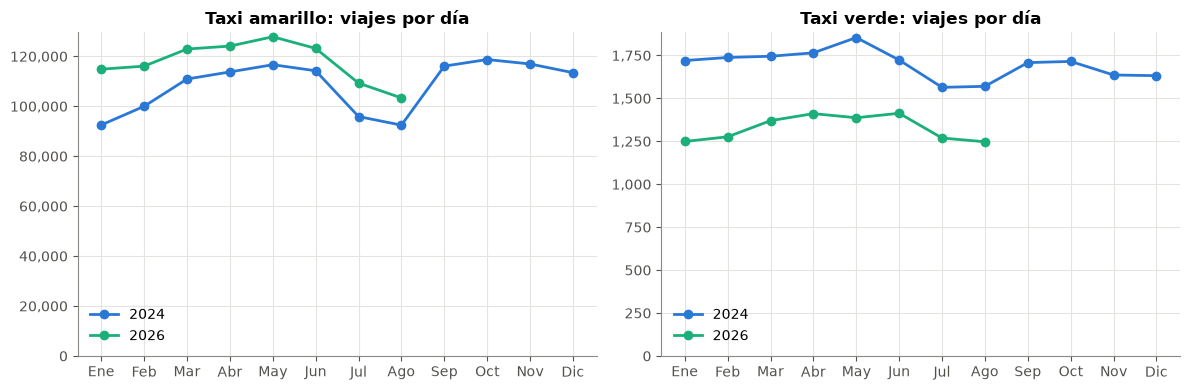

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, taxi in zip(axes, ["yellow", "green"]):
    for year, data in trend[trend.taxi_type == taxi].groupby("year"):
        ax.plot(data.month, data.trips_per_day, marker="o", color=charts.YEAR_COLORS[year], label=str(year))
    ax.set_title(f"Taxi {charts.TAXI_LABELS[taxi].lower()}: viajes por día")
    ax.set_xticks(range(1, 13), charts.MONTHS)
    ax.set_ylim(0, None)
    charts.thousands(ax)
    ax.legend()
plt.tight_layout()
plt.show()

## 5.7 ¿Las consultas anteriores necesitan cambios?

Se ejecutan **todas** las consultas de los Ejercicios 3 y 4 sobre el conjunto ampliado sin modificar su texto.

In [10]:
results = []
for path in sorted((taxi_db.SQL_DIR).glob("0[34]_*/*.sql")):
    name = str(path.relative_to(taxi_db.SQL_DIR))
    start = time.perf_counter()
    try:
        rows = len(taxi_db.query(con, name))
        status = "ok"
    except Exception as error:
        rows, status = 0, f"error: {error}"
    results.append({"query": name, "status": status, "rows": rows, "seconds": round(time.perf_counter() - start, 2)})
pd.DataFrame(results)

,query,status,rows,seconds
0,03_exploration/01_file_inventory.sql,ok,4,0.00
1,03_exploration/02_rows_per_file.sql,ok,40,0.01
2,03_exploration/03_total_rows.sql,ok,3,0.41
3,03_exploration/04_columns_by_file.sql,ok,25,0.01
4,03_exploration/05_column_types_yellow.sql,ok,21,0.00
5,03_exploration/06_column_types_green.sql,ok,22,0.00
6,03_exploration/07_type_conflicts.sql,ok,0,0.00
7,03_exploration/08_sample_yellow.sql,ok,5,0.06
8,03_exploration/09_sample_green.sql,ok,5,0.01
9,03_exploration/10_summary_yellow.sql,ok,21,12.35


Las 31 consultas se ejecutan sin errores. Dos se ajustaron porque su **resultado** perdía sentido al
mezclar años, no porque fallaran:

- `03_exploration/13_pickup_date_range.sql` comparaba contra el año fijo 2026; ahora compara cada viaje
  contra el año de su archivo (`source_year`).
- `04_eda/11_cbd_congestion_fee.sql` agrupaba solo por mes, de modo que enero de 2024 y enero de 2026
  quedaban en el mismo grupo; ahora agrupa por año y mes.

In [11]:
taxi_db.show(con, "03_exploration/13_pickup_date_range.sql")

SELECT
    taxi_type,
    source_year,
    min(pickup_datetime) AS min_pickup,
    max(pickup_datetime) AS max_pickup,
    count(*) FILTER (WHERE year(pickup_datetime) < source_year) AS pickups_before_file_year,
    count(*) FILTER (WHERE year(pickup_datetime) > source_year) AS pickups_after_file_year
FROM trips
GROUP BY taxi_type, source_year
ORDER BY taxi_type DESC, source_year;


,taxi_type,source_year,min_pickup,max_pickup,pickups_before_file_year,pickups_after_file_year
0,yellow,2024,2002-12-31 16:46:07,2026-06-26 23:53:12,49,7
1,yellow,2026,2001-01-01 09:23:58,2026-08-31 23:59:59,17,0
2,green,2024,2008-12-31 00:00:00,2025-01-01 22:21:15,9,11
3,green,2026,2008-12-31 17:35:31,2026-08-31 23:58:28,14,0


In [12]:
taxi_db.show(con, "04_eda/11_cbd_congestion_fee.sql")

SELECT
    taxi_type,
    source_year AS year,
    source_month AS month,
    count(*) AS trips,
    round(100.0 * count(*) FILTER (WHERE cbd_congestion_fee > 0) / count(*), 2) AS pct_with_cbd_fee,
    round(sum(cbd_congestion_fee), 0) AS cbd_fee_collected
FROM trips_clean
GROUP BY ALL
ORDER BY taxi_type DESC, year, month;


,taxi_type,year,month,trips,pct_with_cbd_fee,cbd_fee_collected
0,yellow,2024,1,2868050,0.00,NaN
1,yellow,2024,2,2899878,0.00,NaN
2,yellow,2024,3,3438402,0.00,NaN
3,yellow,2024,4,3412596,0.00,NaN
4,yellow,2024,5,3616087,0.00,NaN
5,yellow,2024,6,3426573,0.00,NaN
6,yellow,2024,7,2972316,0.00,NaN
7,yellow,2024,8,2865750,0.00,NaN
8,yellow,2024,9,3482540,0.00,NaN
9,yellow,2024,10,3680364,0.00,NaN
